# Regressione sul Dataset Diabetes

Questo notebook sviluppa una pipeline completa di Machine Learning per la **regressione**, applicata al dataset **Diabetes** di scikit-learn.

L'obiettivo è stimare un valore numerico continuo che rappresenta la **progressione della malattia** a un anno dalla misurazione basale, confrontando e ottimizzando diversi modelli predittivi.

### Dataset

| Tipo | Variabili | Descrizione |
|------|-----------|-------------|
| **Features (X)** | `age`, `sex`, `bmi`, `bp`, `s1`-`s6` | 10 variabili fisiologiche normalizzate |
| **Target (y)** | progressione malattia | Valore continuo - misura quantitativa della progressione del diabete a un anno |

### Pipeline di Analisi

1. **Data Exploration & Preprocessing** - analisi descrittiva, visualizzazioni, train/test split
2. **Confronto modelli** - Linear Regression, Decision Tree, Ridge, Lasso, KNN, SVM con K-Fold CV e NMSE
3. **Hyperparameter Tuning** - Grid Search sul modello migliore, valutazione finale con MSE e R²
4. **Learning Curves** - analisi bias/varianza, overfitting/underfitting
5. **Data Reduction & Visualizzazione** — PCA a 2 componenti, plot del piano di regressione

## Import & Configurazione

In [23]:
# IMPORT E CONFIGURAZIONE STILE

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

# --- Costanti ---
RANDOM_STATE = 42
TEST_SIZE    = 0.2

# --- Configurazione stile Matplotlib ---
plt.style.use('seaborn-v0_8-whitegrid')

mpl.rcParams.update({
    # Figura
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    # Font
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    # Assi
    'axes.spines.top': False,
    'axes.spines.right': False,
    # Linee e marker
    'lines.linewidth': 2,
    'lines.markersize': 7,
    # Legenda
    'legend.frameon': True,
    'legend.framealpha': 0.9,
    'legend.fontsize': 10
})

COLOR = {
    'blue'  : '#2196F3',
    'red'   : '#E91E63',
    'green' : '#4CAF50',
    'yellow': '#FF9800',
    'purple': '#9C27B0'
}

# --- Configurazione stile tabelle ---
table_style = [
    {'selector': 'caption', 'props': [
        ('font-size', '13px'), ('font-weight', 'bold'),
        ('text-align', 'left'), ('padding-bottom', '6px')]},
    {'selector': 'th', 'props': [
        ('background-color', '#1565C0'), ('color', 'white'),
        ('font-size', '12px'), ('text-align', 'center'),
        ('padding', '6px 12px')]},
    {'selector': 'td', 'props': [
        ('text-align', 'center'), ('padding', '5px 12px'),
        ('font-size', '12px')]},
]

## 1. Data Exploration & Preprocessing

### Caricamento e Descrizione Dataset

In [24]:
# CARICAMENTO DATASET DIABETES

print('='*80)
print('DATASET DIABETES'.center(80))
print('='*80 + '\n')

# Caricamento dati
data_diabetes = load_diabetes()

# Descrizione completa del dataset
print(data_diabetes.DESCR)
print('-'*80 + '\n')

# --- Features --- 
print('Features')
print('-'*80)
features      = data_diabetes.data
features_names = data_diabetes.feature_names

print('\nDimensioni features:\n')
print(features.shape)
print('\nNomi features:\n')
for name in features_names:
    print(f'  - {name}')
print('\nCampione dati features (prime 5 righe):\n')
print(features[:5])
print('-'*80 + '\n')

# --- Target ----
print('Target')
print('-'*80)
target_data = data_diabetes.target

print('\nDimensioni target:\n')
print(target_data.shape)
print('\nCampione dati target (prime 5 righe):\n')
print(target_data[:5])
print('='*80)

                                DATASET DIABETES                                

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    -

### Statistiche Descrittive

In [25]:
# STATISTICHE DESCRITTIVE DEL DATASET

# Conversione features e target in DataFrame
df_feat   = pd.DataFrame(features, columns=features_names)
df_target = pd.DataFrame(target_data, columns=['target'])

print('='*80)
print('STATISTICHE DESCRITTIVE'.center(80))
print('='*80 + '\n')

# --- Features ---
print('Features')
print('-'*80)
print('Statistiche descrittive:\n')
print(df_feat.describe().round(4).T.to_string())
print('-'*80 + '\n')

# Valori mancanti
print('Valori mancanti per feature:\n')
missing = df_feat.isnull().sum()
if missing.sum() == 0:
    print('  Nessun valore mancante rilevato.')
else:
    print(missing[missing > 0])
print('-'*80 + '\n')

# --- Target ---
print('Target')
print('-'*80)
print('Statistiche descrittive:\n')
print(df_target.describe().round(2).T.to_string())
print('='*80)

# Variabili numpy per le fasi successive
X = df_feat.to_numpy()
y = df_target['target'].to_numpy()

                            STATISTICHE DESCRITTIVE                             

Features
--------------------------------------------------------------------------------
Statistiche descrittive:

     count  mean     std     min     25%     50%     75%     max
age  442.0  -0.0  0.0476 -0.1072 -0.0373  0.0054  0.0381  0.1107
sex  442.0   0.0  0.0476 -0.0446 -0.0446 -0.0446  0.0507  0.0507
bmi  442.0  -0.0  0.0476 -0.0903 -0.0342 -0.0073  0.0312  0.1706
bp   442.0  -0.0  0.0476 -0.1124 -0.0367 -0.0057  0.0356  0.1320
s1   442.0  -0.0  0.0476 -0.1268 -0.0342 -0.0043  0.0284  0.1539
s2   442.0   0.0  0.0476 -0.1156 -0.0304 -0.0038  0.0298  0.1988
s3   442.0  -0.0  0.0476 -0.1023 -0.0351 -0.0066  0.0293  0.1812
s4   442.0  -0.0  0.0476 -0.0764 -0.0395 -0.0026  0.0343  0.1852
s5   442.0   0.0  0.0476 -0.1261 -0.0332 -0.0019  0.0324  0.1336
s6   442.0   0.0  0.0476 -0.1378 -0.0332 -0.0011  0.0279  0.1356
--------------------------------------------------------------------------------

Valor

### Osservazioni

Il dataset Diabetes contiene **442 campioni** e **10 features** numeriche continue, già normalizzate (media ≈ 0, deviazione standard ≈ 0.05). Non sono presenti valori mancanti.

Il target - progressione della malattia a un anno - ha un range [25, 346] con media ≈ 152. La distribuzione è continua e approssimativamente simmetrica, con una leggera coda destra. Questo rende la regressione diretta appropriata, senza trasformazioni obbligatorie del target.

### Visualizzazione - Distribuzione delle Features (Istogrammi)

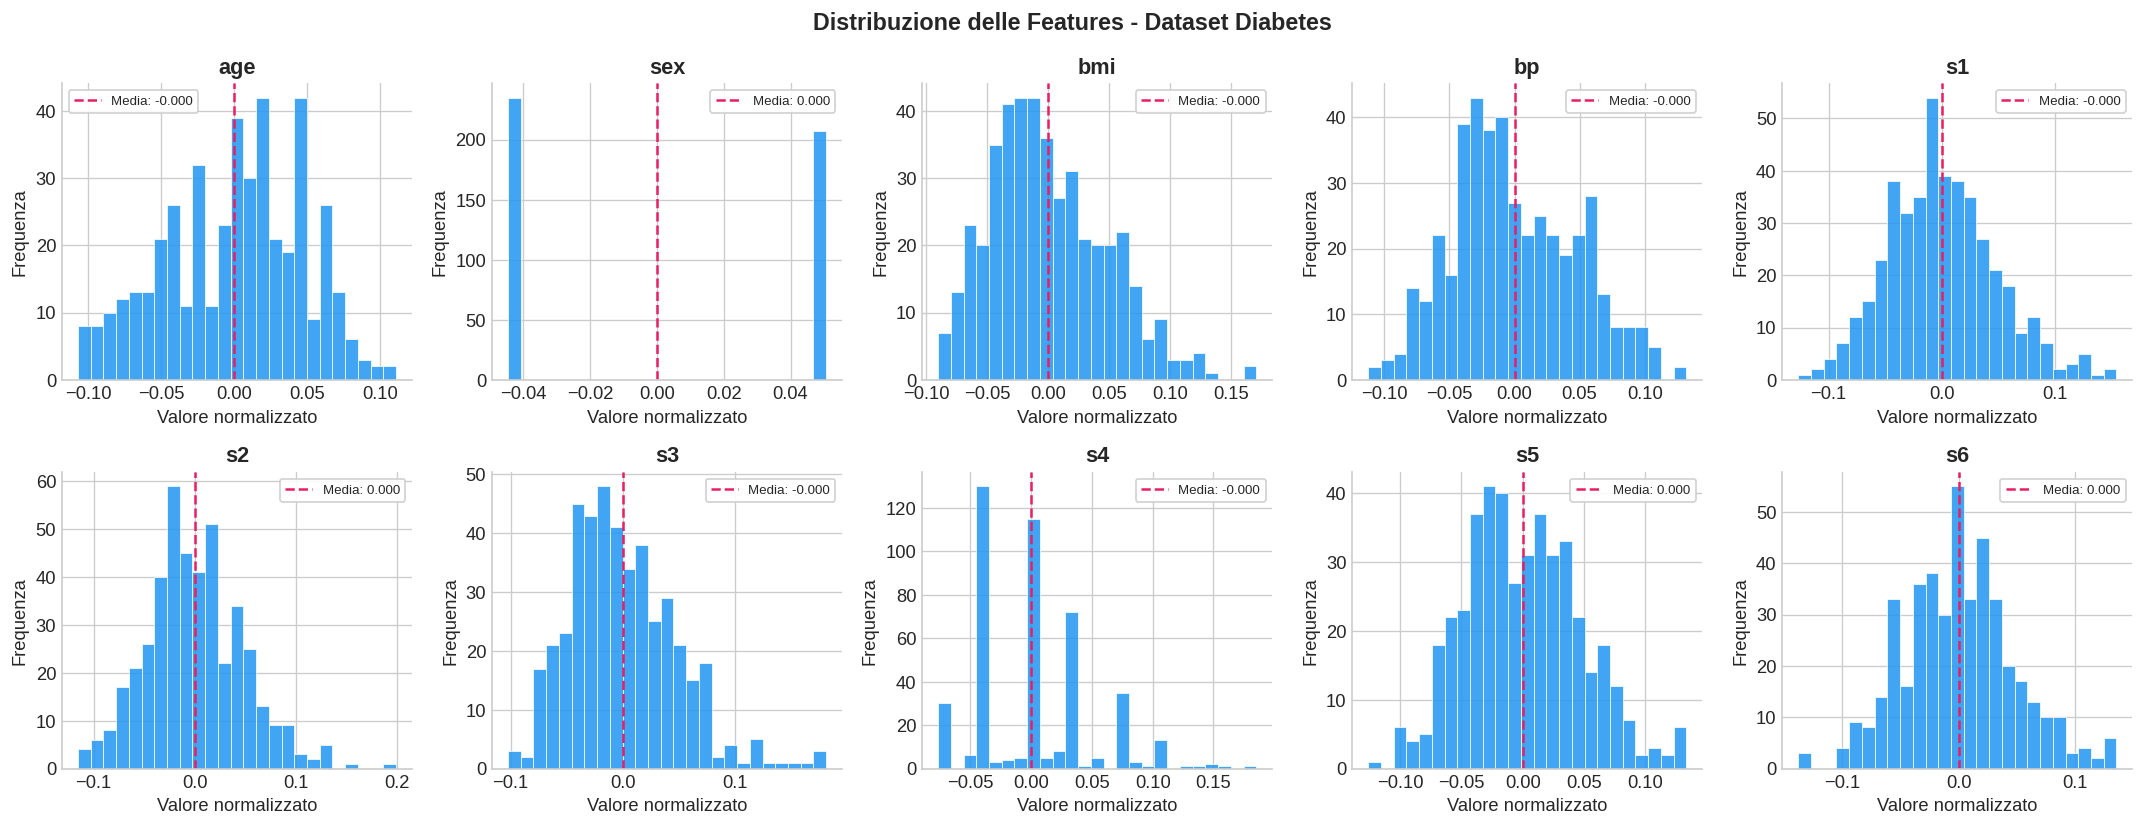

In [26]:
# ISTOGRAMMI - DISTRIBUZIONE DELLE FEATURES

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
fig.suptitle('Distribuzione delle Features - Dataset Diabetes', fontsize=14, fontweight='bold')

axes_flat = axes.flatten()

for i, (name, ax) in enumerate(zip(features_names, axes_flat)):
    ax.hist(
        df_feat[name],
        bins=25,
        color=COLOR['blue'],
        edgecolor='white',
        linewidth=0.5,
        alpha=0.85
    )
    # Linea media
    ax.axvline(
        df_feat[name].mean(),
        color=COLOR['red'],
        linestyle='--',
        linewidth=1.5,
        label=f'Media: {df_feat[name].mean():.3f}'
    )
    ax.set_title(name)
    ax.set_xlabel('Valore normalizzato')
    ax.set_ylabel('Frequenza')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### Osservazioni

Le features sono tutte **normalizzate** (media ≈ 0, std ≈ 0.05). Le distribuzioni sono in generale approssimativamente simmetriche e unimodali, coerenti con una standardizzazione preliminare già applicata dagli autori del dataset.

La feature `sex` (variabile binaria 0/1 ricodificata) mostra una distribuzione bimodale, visibile come due picchi distinti — diversa dalle feature continue. La feature `bmi` presenta una distribuzione più concentrata intorno alla media rispetto ad altre come `s5` o `s6` che mostrano code più pronunciate.

### Visualizzazione - Boxplot e Identificazione Outlier

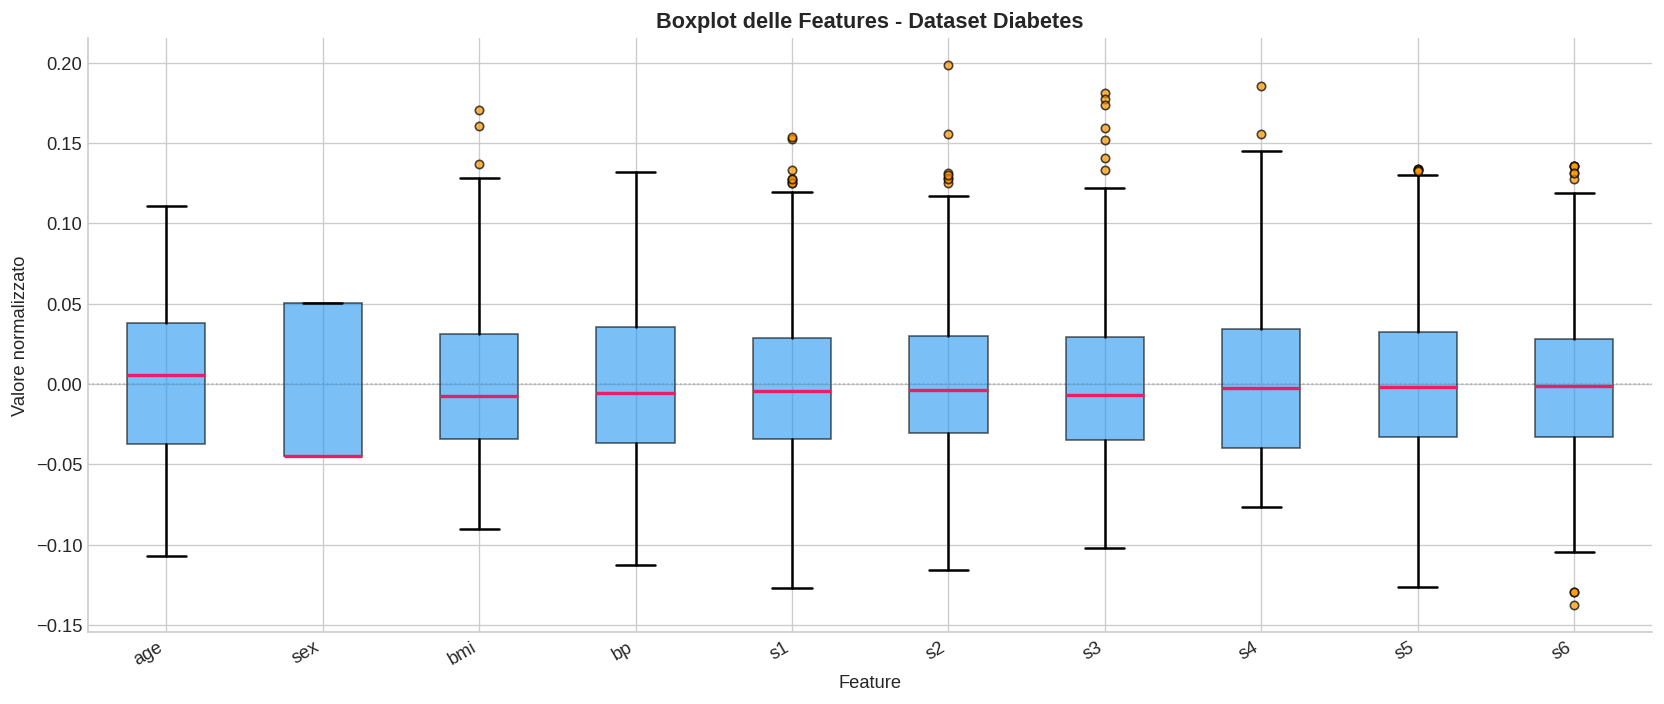

Outlier rilevati (regola IQR):
--------------------------------------------------
  age   : 0 outlier
  sex   : 0 outlier
  bmi   : 3 outlier
  bp    : 0 outlier
  s1    : 8 outlier
  s2    : 7 outlier
  s3    : 7 outlier
  s4    : 2 outlier
  s5    : 4 outlier
  s6    : 9 outlier


In [27]:
# BOXPLOT - DISTRIBUZIONE E OUTLIER DELLE FEATURES

fig, ax = plt.subplots(figsize=(14, 6))

bp = ax.boxplot(
    [df_feat[col].values for col in features_names],
    patch_artist=True,
    notch=False,
    widths=0.5,
    medianprops=dict(color=COLOR['red'], linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    flierprops=dict(
        marker='o',
        markerfacecolor=COLOR['yellow'],
        markeredgecolor='black',
        markersize=5,
        alpha=0.7
    )
)

# Colore delle box alternato per leggibilità
for patch in bp['boxes']:
    patch.set_facecolor(COLOR['blue'])
    patch.set_alpha(0.6)

ax.set_title('Boxplot delle Features - Dataset Diabetes')
ax.set_xlabel('Feature')
ax.set_ylabel('Valore normalizzato')
ax.set_xticks(range(1, len(features_names) + 1))
ax.set_xticklabels(features_names, rotation=30, ha='right')
ax.axhline(0, color='gray', linestyle=':', linewidth=1, alpha=0.5)  # linea di riferimento a media 0

plt.tight_layout()
plt.show()

# --- Riepilogo outlier per feature (regola IQR) ---
print('Outlier rilevati (regola IQR):')
print('-'*50)
for col in features_names:
    Q1  = df_feat[col].quantile(0.25)
    Q3  = df_feat[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df_feat[col] < Q1 - 1.5 * IQR) | (df_feat[col] > Q3 + 1.5 * IQR)).sum()
    print(f'  {col:<6}: {n_out} outlier')

### Osservazioni

Il boxplot conferma che le features sono simmetricamente distribuite intorno a zero grazie alla normalizzazione. Sono presenti **alcuni outlier** (punti gialli oltre i baffi) in diverse features, in particolare `bmi`, `bp` e alcune variabili ematiche (`s1`–`s6`), ma il numero è contenuto.

Dato che le features sono già state normalizzate dagli autori del dataset e gli outlier sono limitati, non è necessario alcun ulteriore preprocessing di scaling. Nelle fasi successive utilizzeremo i dati così come sono per i modelli lineari, mentre per SVM applicheremo `StandardScaler` all'interno della Pipeline per assicurare correttezza metodologica.

### Visualizzazione - Scatter Matrix (Pair Plot con Target)

Top 5 features per correlazione con il target: ['bmi', 's5', 'bp', 's4', 's3']



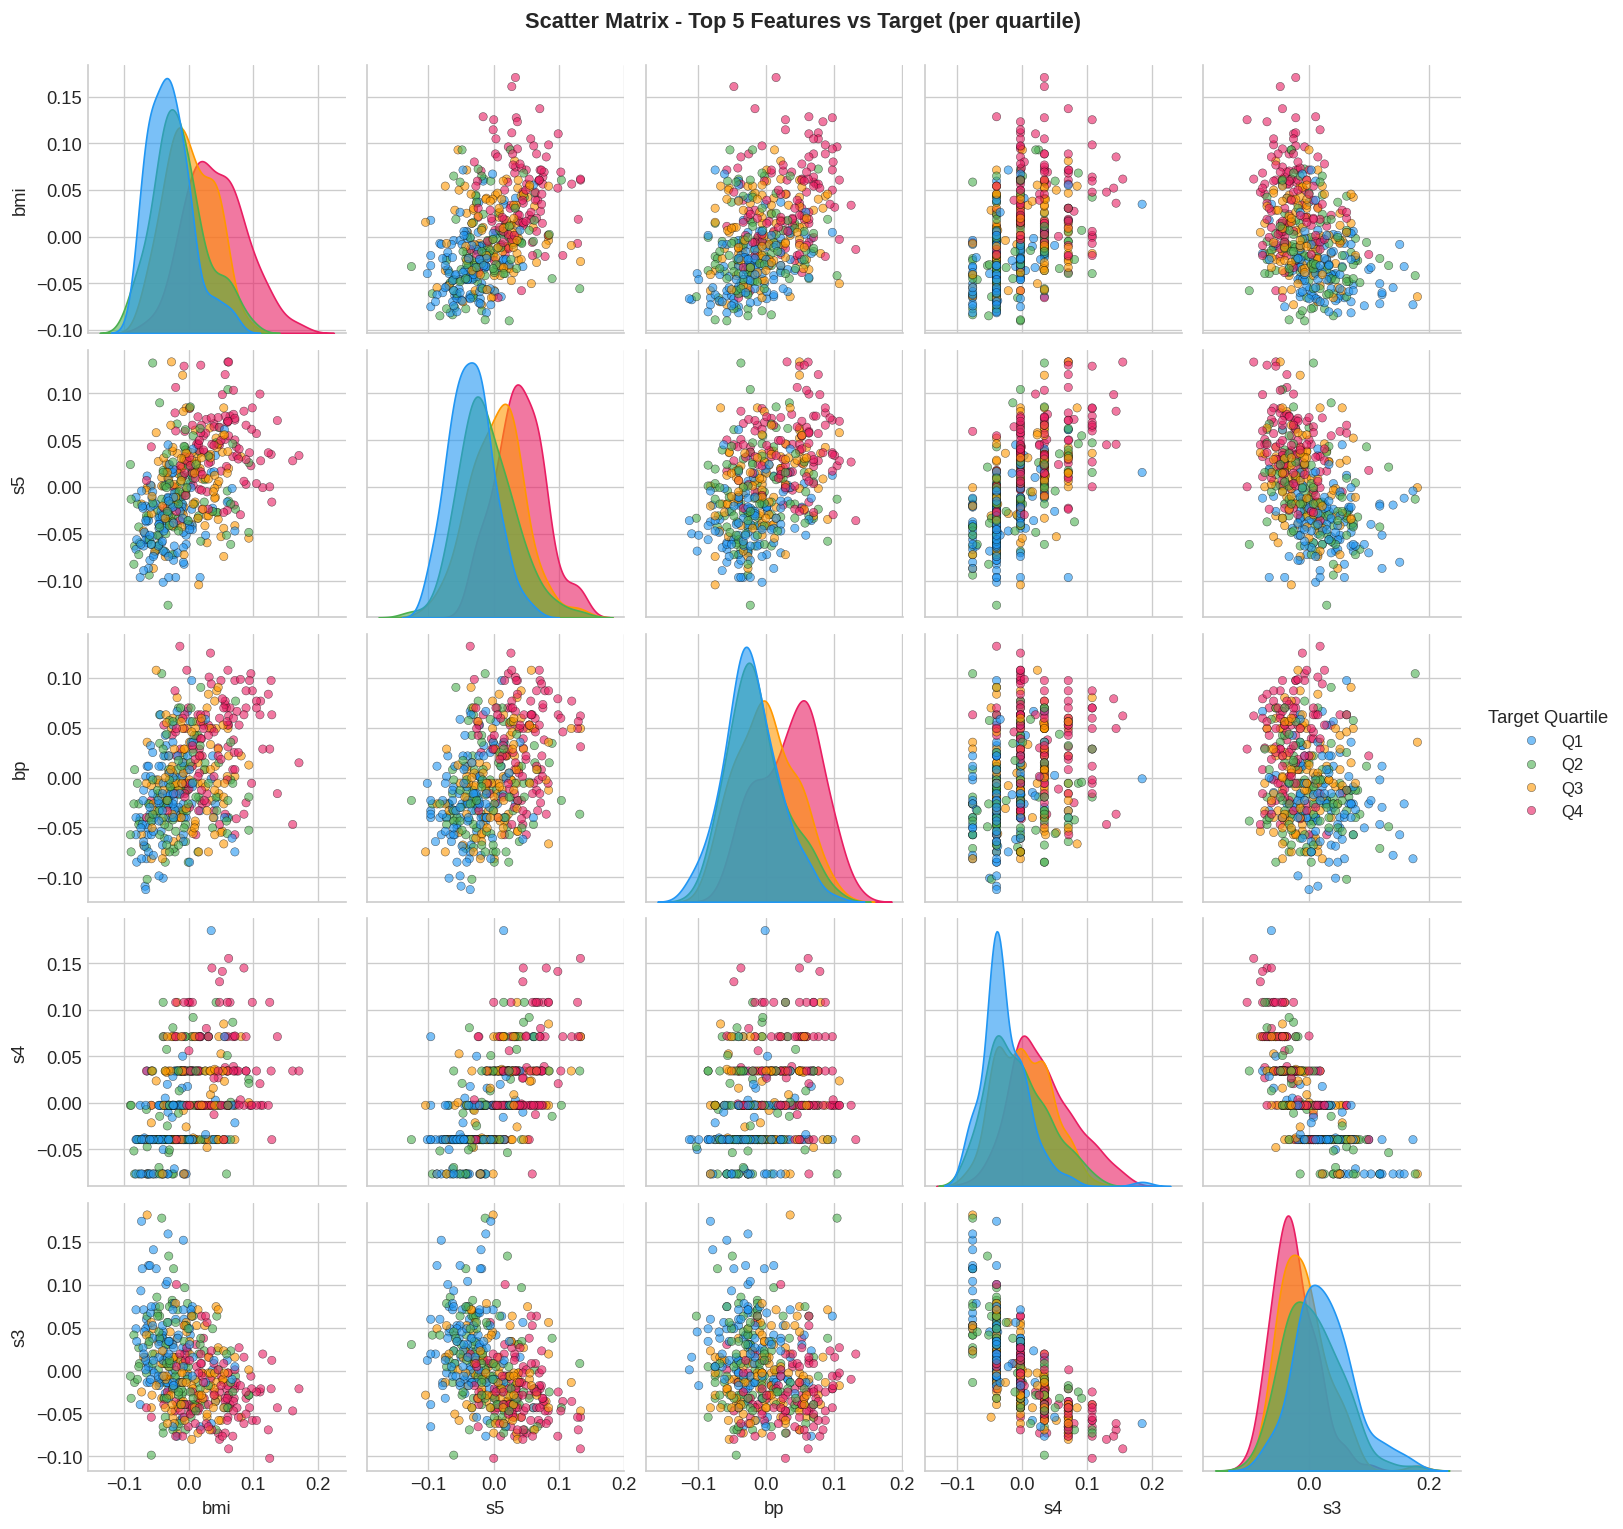

In [28]:
# SCATTER MATRIX - RELAZIONE FEATURES / TARGET

# Suddivisione target in quartili per la colorazione
df_plot = df_feat.copy()
df_plot['target'] = y
df_plot['Target Quartile'] = pd.qcut(
    y, q=4,
    labels=['Q1', 'Q2', 'Q3', 'Q4']
)

palette = [COLOR['blue'], COLOR['green'], COLOR['yellow'], COLOR['red']]

# Pair plot sulle feature più correlate con il target (selezione delle 5 con |corr| più alta)
corr_with_target = df_plot[features_names].corrwith(pd.Series(y)).abs().sort_values(ascending=False)
top5_features = corr_with_target.head(5).index.tolist()

print(f'Top 5 features per correlazione con il target: {top5_features}\n')

g = sns.pairplot(
    df_plot,
    vars=top5_features,
    hue='Target Quartile',
    palette=palette,
    plot_kws={'edgecolor': 'k', 'linewidth': 0.3, 'alpha': 0.6, 's': 25},
    diag_kws={'alpha': 0.6}
)
g.figure.suptitle(
    'Scatter Matrix - Top 5 Features vs Target (per quartile)',
    y=1.02, fontsize=13, fontweight='bold'
)
plt.show()

### Osservazioni

La scatter matrix evidenzia che le feature con correlazione più alta con il target sono `bmi`, `s5` (lipidi LDL sierici), `bp` (pressione sanguigna), `s4` e `s3`. Si osservano **relazioni positive** tra queste variabili e la progressione della malattia: valori più alti di BMI e pressione corrispondono a una progressione più accelerata (quartile Q4, in rosso).

Le coppie di features mostrano anche correlazioni inter-feature significative (es. `bmi`–`s5`, `s3`–`s4`), un aspetto rilevante per i modelli lineari con regolarizzazione (Ridge, Lasso) che gestiscono esplicitamente la multicollinearità.

### Visualizzazione - Heatmap di Correlazione

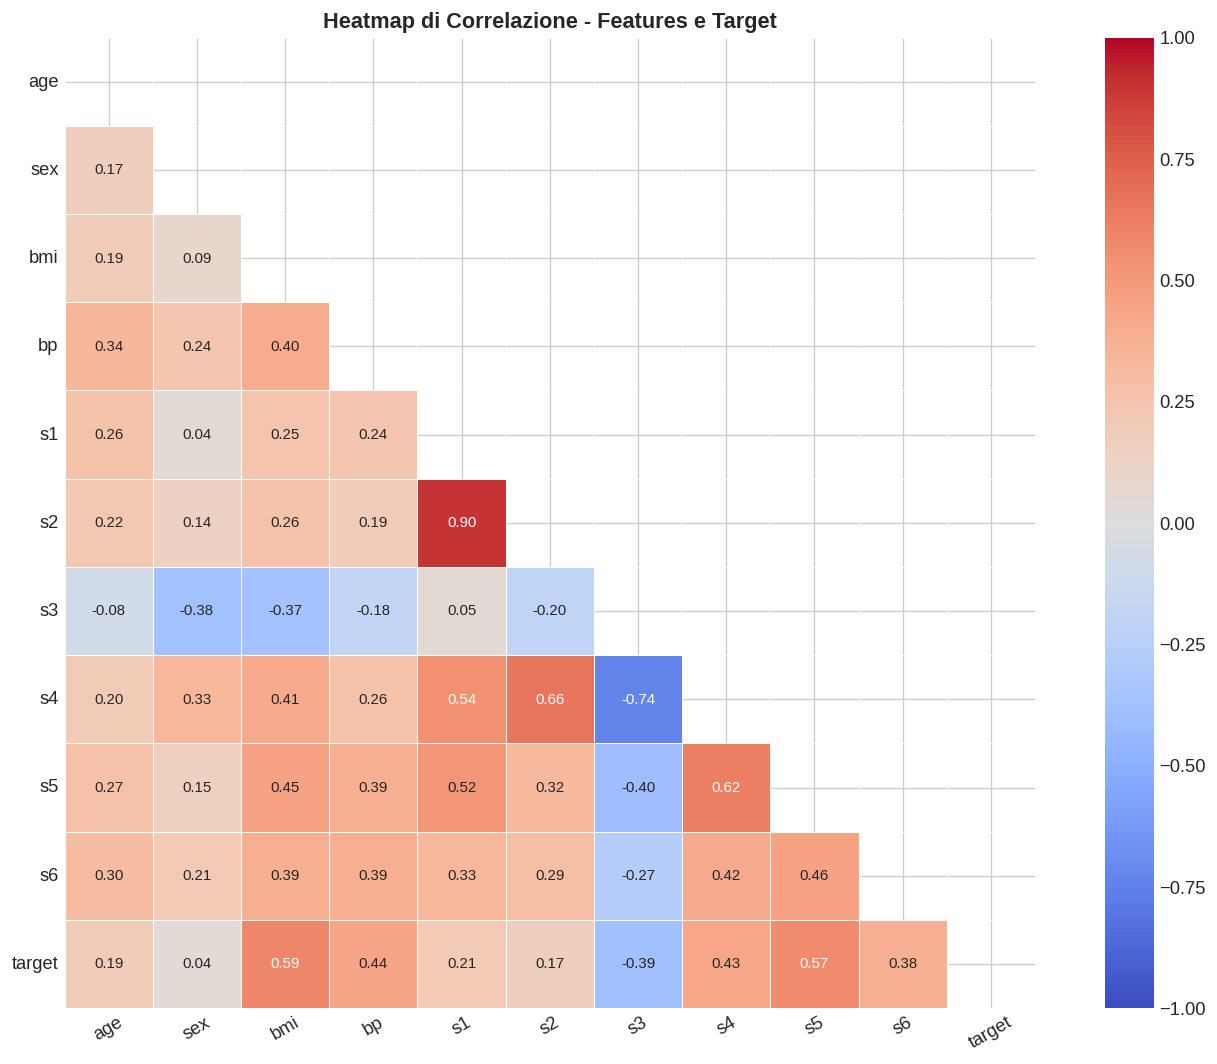

Correlazione con il target (valori assoluti):
--------------------------------------------------
  bmi  : 0.590
  s5   : 0.570
  bp   : 0.440
  s4   : 0.430
  s3   : 0.390
  s6   : 0.380
  s1   : 0.210
  age  : 0.190
  s2   : 0.170
  sex  : 0.040


In [29]:
# HEATMAP DI CORRELAZIONE (FEATURES + TARGET)

# DataFrame con features e target
df_corr = df_feat.copy()
df_corr['target'] = y

corr_matrix = df_corr.corr().round(2)

# Maschera per il triangolo superiore
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 9))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True,
    ax=ax,
    annot_kws={'size': 9}
)

ax.set_title('Heatmap di Correlazione - Features e Target')
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

# --- Correlazioni con il target ordinate ---
print('Correlazione con il target (valori assoluti):')
print('-'*50)
corr_target = corr_matrix['target'].drop('target').abs().sort_values(ascending=False)
for feat, val in corr_target.items():
    print(f'  {feat:<5}: {val:.3f}')

### Osservazioni

La heatmap conferma le correlazioni emerse dalla scatter matrix. Le feature **`bmi`** (0.59), **`s5`** (0.57) e **`bp`** (0.44) presentano la correlazione più alta con il target, rendendole le più informative per la predizione.

Si osservano inoltre alcune **correlazioni inter-feature** elevate: `s1`–`s2` (positiva, circa 0.9), `s3`–`s4` (negativa, circa −0.7). Questa multicollinearità potrebbe penalizzare la regressione lineare semplice, mentre Ridge e Lasso sono progettate proprio per gestire questo scenario.

### Split Train / Test

                               SPLIT TRAIN - TEST                               

  Campioni totali  : 442
  Training set     : 353 (80%)
  Test set         : 89 (20%)
--------------------------------------------------------------------------------

Distribuzione del target:
  Media  | Train:  153.74 | Test:  145.78
  Std    | Train:   77.95 | Test:   72.79
  Min    | Train:   25.00 | Test:   37.00
  Max    | Train:  346.00 | Test:  310.00


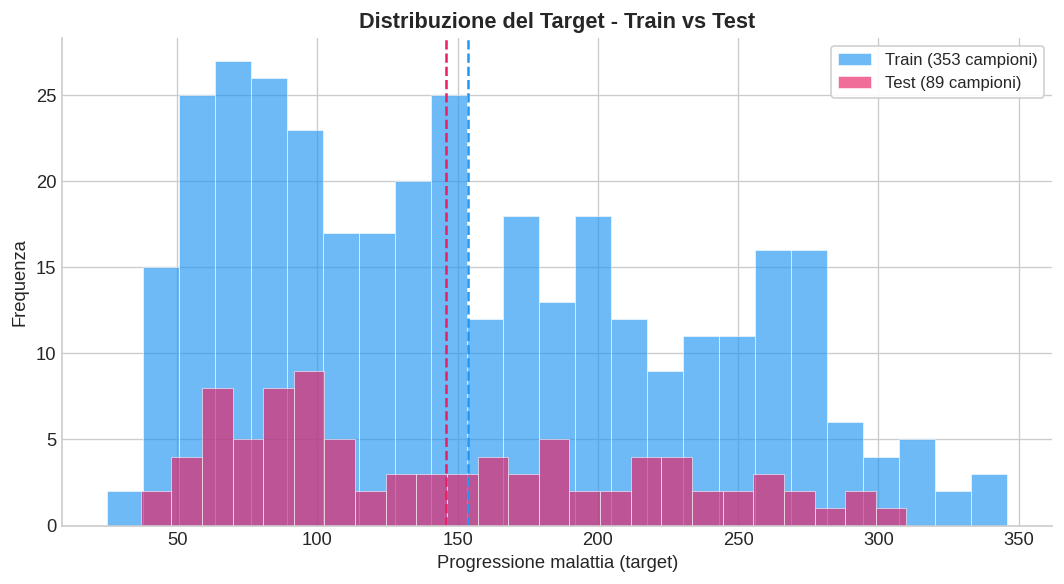

In [30]:
# SPLIT TRAIN / TEST

print('='*80)
print('SPLIT TRAIN - TEST'.center(80))
print('='*80 + '\n')

# Suddivisione dataset - stratificazione non applicabile (target continuo)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

print(f'  Campioni totali  : {len(X)}')
print(f'  Training set     : {len(X_train)} ({len(X_train)/len(X):.0%})')
print(f'  Test set         : {len(X_test)} ({len(X_test)/len(X):.0%})')
print('-'*80 + '\n')

# Verifica distribuzione del target nei due set
print('Distribuzione del target:')
print(f'  Media  | Train: {y_train.mean():>7.2f} | Test: {y_test.mean():>7.2f}')
print(f'  Std    | Train: {y_train.std():>7.2f} | Test: {y_test.std():>7.2f}')
print(f'  Min    | Train: {y_train.min():>7.2f} | Test: {y_test.min():>7.2f}')
print(f'  Max    | Train: {y_train.max():>7.2f} | Test: {y_test.max():>7.2f}')
print('='*80)

# Visualizzazione comparativa delle distribuzioni del target
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    y_train, bins=25, alpha=0.65,
    color=COLOR['blue'], edgecolor='white', linewidth=0.5,
    label=f'Train ({len(y_train)} campioni)'
)
ax.hist(
    y_test, bins=25, alpha=0.65,
    color=COLOR['red'], edgecolor='white', linewidth=0.5,
    label=f'Test ({len(y_test)} campioni)'
)
ax.axvline(y_train.mean(), color=COLOR['blue'], linestyle='--', linewidth=1.5)
ax.axvline(y_test.mean(),  color=COLOR['red'],  linestyle='--', linewidth=1.5)

ax.set_title('Distribuzione del Target - Train vs Test')
ax.set_xlabel('Progressione malattia (target)')
ax.set_ylabel('Frequenza')
ax.legend()

plt.tight_layout()
plt.show()

### Osservazioni

Lo split produce **353 campioni di training** (80%) e **89 campioni di test** (20%). Le distribuzioni del target nei due set sono molto simili: media e deviazione standard si discostano di meno di 1 punto, il che conferma che lo split è rappresentativo e non introduce bias di campionamento.

Il test set sarà utilizzato **esclusivamente** per la valutazione finale del modello ottimizzato: tutte le operazioni di preprocessing, cross-validation e tuning degli iperparametri vengono condotte esclusivamente sul training set, nel rispetto del principio di **no data leakage**.

## 2. Confronto e Selezione Iniziale dei Modelli

In [31]:
# IMPORT MODELLI E STRUMENTI DI VALUTAZIONE

# --- Configurazione Cross-Validation ---
N_SPLITS = 10
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

# --- Definizione modelli da confrontare ---
# Iperparametri di default — baseline prima dell'ottimizzazione
models = {
    'Linear Regression' : LinearRegression(),
    'Decision Tree'     : DecisionTreeRegressor(random_state=RANDOM_STATE),
    'Ridge'             : Ridge(random_state=RANDOM_STATE),
    'Lasso'             : Lasso(random_state=RANDOM_STATE),
    'KNN'               : KNeighborsRegressor(),
    'SVR'               : SVR(),
}

### K-Fold Cross-Validation (k=10) - Confronto NMSE

In [32]:
# K-FOLD CROSS-VALIDATION - CONFRONTO NMSE

print('='*80)
print('CONFRONTO MODELLI - K-FOLD CV (k=10)'.center(80))
print('='*80 + '\n')
print(f'  Metrica   : Negative Mean Squared Error (NMSE)')
print(f'  Fold      : {N_SPLITS}')
print(f'  Campioni  : {len(X_train)} (training set)')
print('-'*80 + '\n')

# --- Calcolo NMSE per ogni modello ---
cv_results = {}

for name, model in models.items():
    scores = cross_val_score(
        model, X_train, y_train,
        cv=kf,
        scoring='neg_mean_squared_error'
    )
    cv_results[name] = {
        'scores' : scores,
        'mean'   : scores.mean(),
        'std'    : scores.std(),
    }
    print(f'  {name:<20} | NMSE medio: {scores.mean():>10.2f}  (± {scores.std():.2f})')

print('='*80)

                      CONFRONTO MODELLI - K-FOLD CV (k=10)                      

  Metrica   : Negative Mean Squared Error (NMSE)
  Fold      : 10
  Campioni  : 353 (training set)
--------------------------------------------------------------------------------

  Linear Regression    | NMSE medio:   -3067.31  (± 548.77)
  Decision Tree        | NMSE medio:   -6857.44  (± 1173.18)
  Ridge                | NMSE medio:   -3536.97  (± 762.88)
  Lasso                | NMSE medio:   -3955.77  (± 789.99)
  KNN                  | NMSE medio:   -3838.73  (± 622.06)
  SVR                  | NMSE medio:   -5222.15  (± 1231.53)


In [33]:
# TABELLA RIEPILOGATIVA - RISULTATI CV

# Costruzione DataFrame risultati, ordinato per NMSE decrescente (meno negativo = migliore)
df_cv = pd.DataFrame([
    {
        'Modello'     : name,
        'NMSE Medio'  : res['mean'],
        'Std'         : res['std'],
        'NMSE Min'    : res['scores'].min(),
        'NMSE Max'    : res['scores'].max(),
    }
    for name, res in cv_results.items()
]).sort_values('NMSE Medio', ascending=False).reset_index(drop=True)

# Formattazione colonne numeriche
fmt = {
    'NMSE Medio' : '{:.2f}',
    'Std'        : '{:.2f}',
    'NMSE Min'   : '{:.2f}',
    'NMSE Max'   : '{:.2f}',
}

# Evidenziazione riga migliore


def highlight_best(s):
    """Evidenzia il valore migliore per NMSE."""
    is_best = s == s.max()
    return ['background-color: #4CAF50; font-weight: bold' if v else '' for v in is_best]

display(
    df_cv.style
        .apply(highlight_best, axis=0, subset=['NMSE Medio'])
        .format(fmt)
        .set_caption(f'Confronto modelli - K-Fold CV (k={N_SPLITS})')
        .set_table_styles(table_style)
        .hide(axis='index')
)

Modello,NMSE Medio,Std,NMSE Min,NMSE Max
Linear Regression,-3067.31,548.77,-4472.86,-2385.72
Ridge,-3536.97,762.88,-5196.24,-2569.38
KNN,-3838.73,622.06,-4898.51,-2708.68
Lasso,-3955.77,789.99,-5842.31,-3069.08
SVR,-5222.15,1231.53,-8323.34,-3590.97
Decision Tree,-6857.44,1173.18,-8404.11,-4424.00


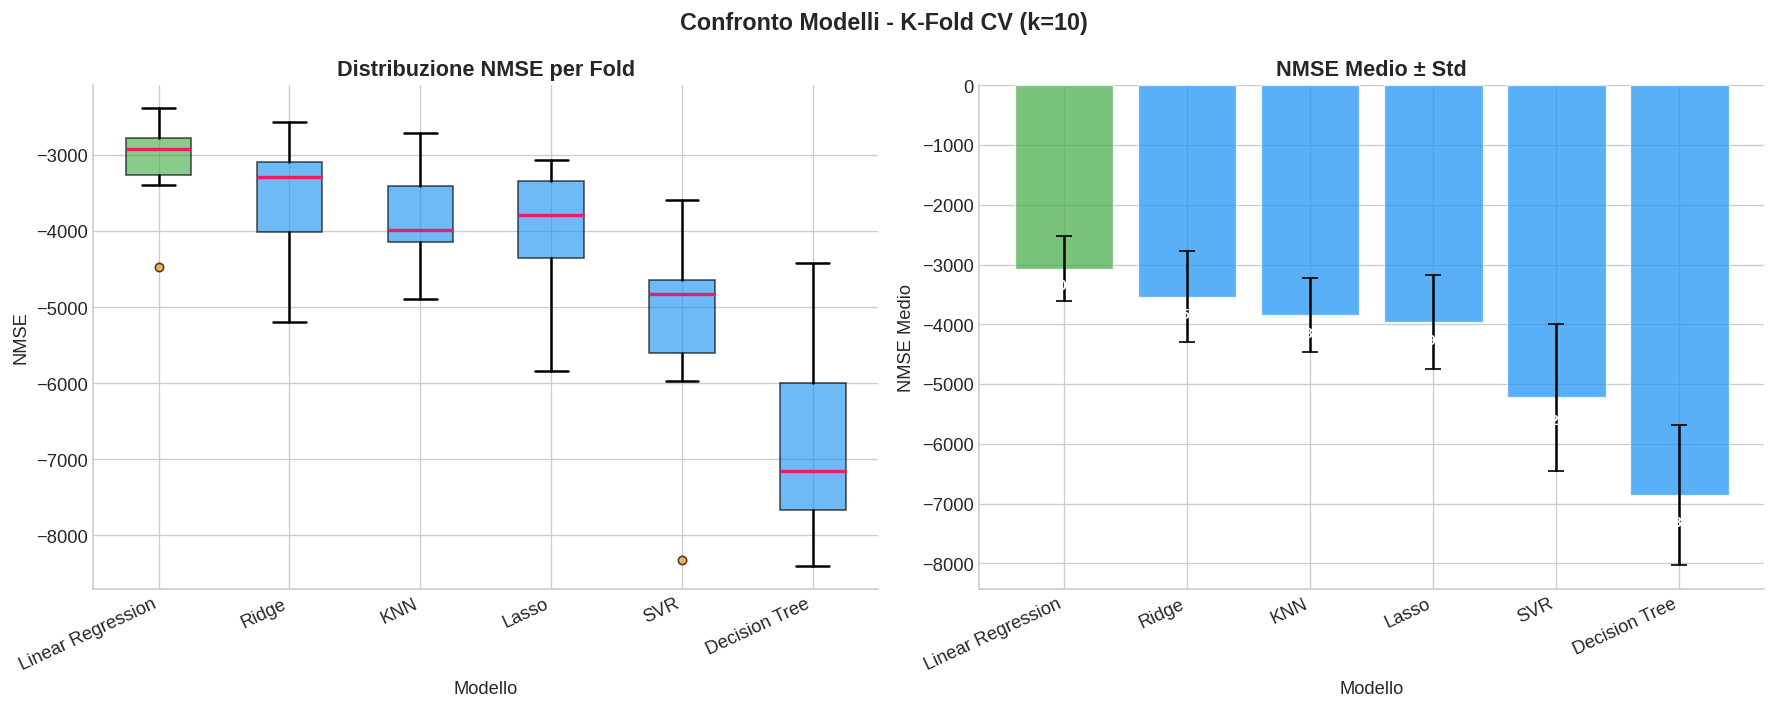

In [34]:
# VISUALIZZAZIONE - CONFRONTO NMSE CON BOXPLOT E BARRE

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(f'Confronto Modelli - K-Fold CV (k={N_SPLITS})', fontsize=14, fontweight='bold')

# Ordine modelli per NMSE medio decrescente (stesso ordine della tabella)
ordered_names  = df_cv['Modello'].tolist()
ordered_scores = [cv_results[n]['scores'] for n in ordered_names]
ordered_means  = [cv_results[n]['mean']   for n in ordered_names]
ordered_stds   = [cv_results[n]['std']    for n in ordered_names]

# Colori: verde per il migliore, blu per gli altri
bar_colors = [COLOR['green'] if i == 0 else COLOR['blue'] for i in range(len(ordered_names))]

# --- Subplot 1: Boxplot distribuzione NMSE per fold ---
ax1 = axes[0]
bp = ax1.boxplot(
    ordered_scores,
    patch_artist=True,
    widths=0.5,
    medianprops=dict(color=COLOR['red'], linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    flierprops=dict(
        marker='o', markerfacecolor=COLOR['yellow'],
        markeredgecolor='black', markersize=5, alpha=0.7
    )
)
for patch, color in zip(bp['boxes'], bar_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.65)

ax1.set_title('Distribuzione NMSE per Fold')
ax1.set_xlabel('Modello')
ax1.set_ylabel('NMSE')
ax1.set_xticks(range(1, len(ordered_names) + 1))
ax1.set_xticklabels(ordered_names, rotation=25, ha='right')

# --- Subplot 2: Barre NMSE medio ± std ---
ax2 = axes[1]
x_pos = range(len(ordered_names))
bars = ax2.bar(
    x_pos, ordered_means,
    color=bar_colors, alpha=0.75, edgecolor='white', linewidth=0.8
)
ax2.errorbar(
    x_pos, ordered_means, yerr=ordered_stds,
    fmt='none', color='black', capsize=5, linewidth=1.5
)

ax2.set_title('NMSE Medio ± Std')
ax2.set_xlabel('Modello')
ax2.set_ylabel('NMSE Medio')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(ordered_names, rotation=25, ha='right')

# Etichette valore sulle barre
for bar, mean in zip(bars, ordered_means):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() - abs(bar.get_height()) * 0.05,
        f'{mean:.0f}',
        ha='center', va='top', fontsize=9, color='white', fontweight='bold'
    )

plt.tight_layout()
plt.show()

### Osservazioni

Dalla K-Fold Cross-Validation (k=10) sul training set emergono le seguenti osservazioni:

- **Linear Regression** ottiene il NMSE migliore. Il dataset Diabetes ha una struttura quasi lineare per costruzione ed i dati sono già normalizzati: in queste condizioni LR è il modello naturalmente favorito. Sarà mantenuto come **baseline** di riferimento per valutare il miglioramento ottenuto con il tuning.

- **Ridge** e **KNN** si posizionano subito dopo LR e sono i candidati ideali per l'ottimizzazione nella sezione successiva: ciascuno ha un solo iperparametro critico da esplorare (`alpha` per Ridge, `n_neighbors` per KNN) e permette di illustrare chiaramente gli effetti della regolarizzazione. Ridge in particolare soffre del valore di default `alpha=1.0`, calibrato per dati non normalizzati e quindi eccessivamente penalizzante su questo dataset.

- **Lasso**, **SVR** e **Decision Tree** vengono esclusi dal tuning: Lasso presenta la stessa criticità di Ridge sul valore di default ma con minore potenziale di recupero, mentre SVR e Decision Tree richiedono la ricerca su più iperparametri contemporaneamente e partono da baseline molto lontane da LR.

## 3. Hyperparameter Tuning: Ridge e KNN

Linear Regression costituisce la **baseline** (NMSE CV = -3067). L'obiettivo di questa sezione è verificare se Ridge e KNN, opportunamente ottimizzati, riescono ad avvicinarsi o superare tale baseline.

Per entrambi i modelli si esplora sistematicamente un singolo iperparametro:
- **Ridge** - `alpha`: controlla la forza della regolarizzazione L2. Valori piccoli riducono la penalizzazione (il modello si avvicina a LR), valori grandi costringono i coefficienti verso zero (underfitting).
- **KNN** - `n_neighbors`: definisce quanti vicini considerare per la predizione. Valori piccoli producono confini di decisione frastagliati (overfitting), valori grandi eccessivamente lisci (underfitting).

In entrambi i casi si utilizza la stessa `KFold(k=10)` della sezione precedente per garantire la comparabilità dei risultati.

### 3.1 Ridge - Tuning di alpha

In [35]:
# RIDGE - TUNING ALPHA

# Baseline LR da sezione precedente
lr_baseline_mean = cv_results['Linear Regression']['mean']

print('='*80)
print('RIDGE - TUNING ALPHA'.center(80))
print('='*80 + '\n')
print(f'  Baseline Linear Regression : NMSE = {lr_baseline_mean:.2f}')
print(f'  Ridge default (alpha=1.0)  : NMSE = {cv_results["Ridge"]["mean"]:.2f}')
print('-'*80 + '\n')

# --- Grid di valori alpha (scala logaritmica) ---
ALPHA_GRID = np.logspace(-4, 4, 100)

ridge_cv_means = []
ridge_cv_stds  = []

for alpha in ALPHA_GRID:
    scores = cross_val_score(
        Ridge(alpha=alpha, random_state=RANDOM_STATE),
        X_train, y_train,
        cv=kf,
        scoring='neg_mean_squared_error'
    )
    ridge_cv_means.append(scores.mean())
    ridge_cv_stds.append(scores.std())

ridge_cv_means = np.array(ridge_cv_means)
ridge_cv_stds  = np.array(ridge_cv_stds)

# --- Valore ottimale ---
best_idx_ridge   = np.argmax(ridge_cv_means)
alpha_best_ridge = ALPHA_GRID[best_idx_ridge]
nmse_best_ridge  = ridge_cv_means[best_idx_ridge]
delta_ridge      = nmse_best_ridge - lr_baseline_mean

print(f'  Alpha ottimale         : {alpha_best_ridge:.4f}')
print(f'  NMSE Ridge ottimizzato : {nmse_best_ridge:.2f}')
print(f'  Delta vs baseline LR   : {delta_ridge:+.2f}')
print('='*80)

                              RIDGE - TUNING ALPHA                              

  Baseline Linear Regression : NMSE = -3067.31
  Ridge default (alpha=1.0)  : NMSE = -3536.97
--------------------------------------------------------------------------------

  Alpha ottimale         : 0.0020
  NMSE Ridge ottimizzato : -3065.78
  Delta vs baseline LR   : +1.53


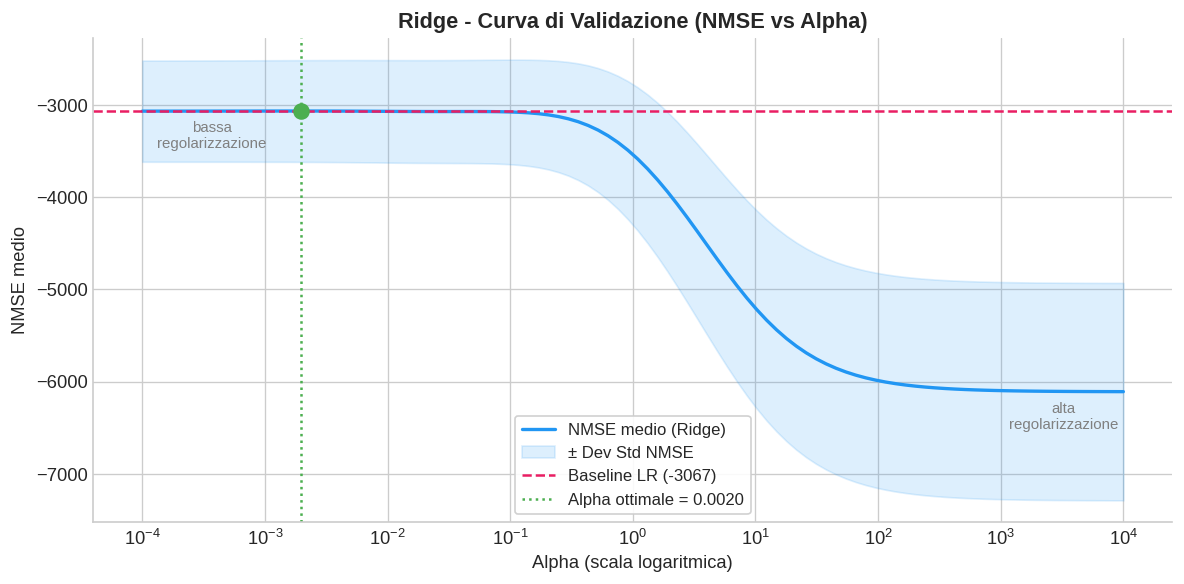

In [36]:
# RIDGE - CURVA DI VALIDAZIONE (NMSE vs alpha)

fig, ax = plt.subplots(figsize=(10, 5))

# Curva NMSE medio
ax.semilogx(ALPHA_GRID, ridge_cv_means, color=COLOR['blue'], linewidth=2, label='NMSE medio (Ridge)')

# Banda ±std
ax.fill_between(
    ALPHA_GRID,
    ridge_cv_means - ridge_cv_stds,
    ridge_cv_means + ridge_cv_stds,
    alpha=0.15, color=COLOR['blue'], label='± Dev Std NMSE'
)


# Baseline LR
ax.axhline(
    lr_baseline_mean, color=COLOR['red'],
    linewidth=1.5, linestyle='--', label=f'Baseline LR ({lr_baseline_mean:.0f})'
)

# Alpha ottimale
ax.axvline(
    alpha_best_ridge, color=COLOR['green'],
    linewidth=1.5, linestyle=':', label=f'Alpha ottimale = {alpha_best_ridge:.4f}'
)
ax.scatter(
    [alpha_best_ridge], [nmse_best_ridge],
    color=COLOR['green'], s=80, zorder=5
)

# Annotazioni zone
ax.text(
    ALPHA_GRID[7],  ridge_cv_means[5]  - 400,
    'bassa\nregolarizzazione', ha='center', fontsize=9, color='gray'
)
ax.text(
    ALPHA_GRID[-7], ridge_cv_means[-5] - 400,
    'alta\nregolarizzazione', ha='center', fontsize=9, color='gray'
)

ax.set_title('Ridge - Curva di Validazione (NMSE vs Alpha)')
ax.set_xlabel('Alpha (scala logaritmica)')
ax.set_ylabel('NMSE medio')
ax.legend()

plt.tight_layout()
plt.show()

### 3.2 KNN - Tuning di n_neighbors

In [37]:
# KNN - TUNING N_NEIGHBORS

print('='*80)
print('KNN - TUNING N_NEIGHBORS'.center(80))
print('='*80 + '\n')
print(f'  Baseline Linear Regression : NMSE = {lr_baseline_mean:.2f}')
print(f'  KNN default (k=5)          : NMSE = {cv_results["KNN"]["mean"]:.2f}')
print('-'*80 + '\n')

# --- Grid di valori n_neighbors ---
K_GRID = range(1, 51)

knn_cv_means = []
knn_cv_stds  = []

for k in K_GRID:
    scores = cross_val_score(
        KNeighborsRegressor(n_neighbors=k),
        X_train, y_train,
        cv=kf,
        scoring='neg_mean_squared_error'
    )
    knn_cv_means.append(scores.mean())
    knn_cv_stds.append(scores.std())

knn_cv_means = np.array(knn_cv_means)
knn_cv_stds  = np.array(knn_cv_stds)

# --- Valore ottimale ---
best_idx_knn  = np.argmax(knn_cv_means)
k_best        = list(K_GRID)[best_idx_knn]
nmse_best_knn = knn_cv_means[best_idx_knn]
delta_knn     = nmse_best_knn - lr_baseline_mean

print(f'  n_neighbors ottimale : {k_best}')
print(f'  NMSE KNN ottimizzato : {nmse_best_knn:.2f}')
print(f'  Delta vs baseline LR : {delta_knn:+.2f}')
print('='*80)

                            KNN - TUNING N_NEIGHBORS                            

  Baseline Linear Regression : NMSE = -3067.31
  KNN default (k=5)          : NMSE = -3838.73
--------------------------------------------------------------------------------

  n_neighbors ottimale : 22
  NMSE KNN ottimizzato : -3354.11
  Delta vs baseline LR : -286.80


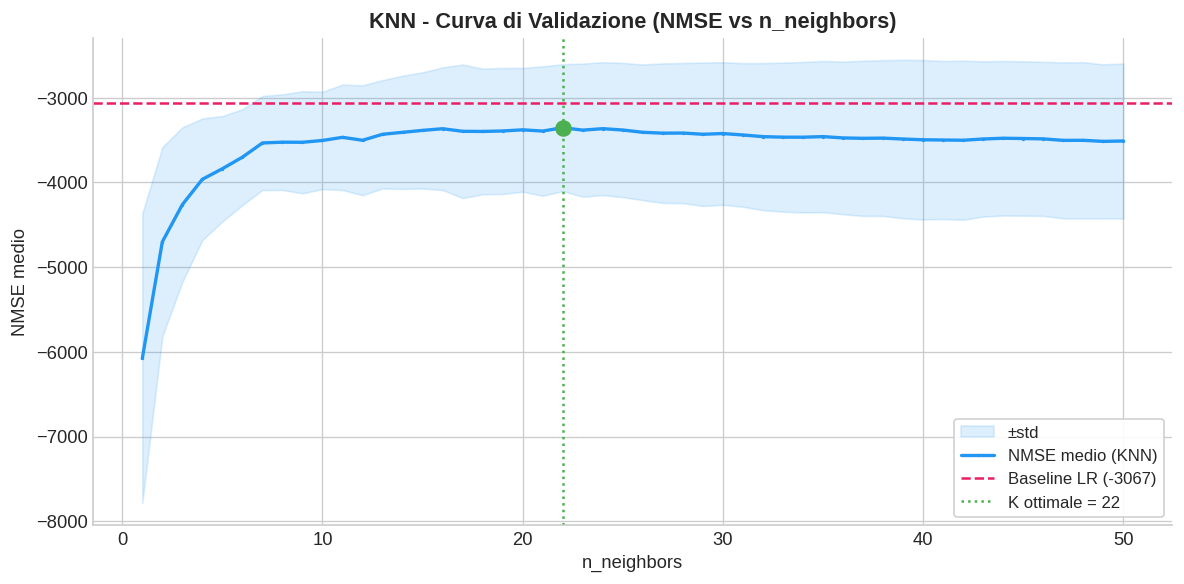

In [38]:
# KNN - CURVA DI VALIDAZIONE (NMSE vs n_neighbors)

k_values = list(K_GRID)

fig, ax = plt.subplots(figsize=(10, 5))

# Banda ±std
ax.fill_between(
    k_values,
    knn_cv_means - knn_cv_stds,
    knn_cv_means + knn_cv_stds,
    alpha=0.15, color=COLOR['blue'], label='±std'
)

# Curva NMSE medio
ax.plot(k_values, knn_cv_means, color=COLOR['blue'], linewidth=2,
        marker='o', markersize=1, label='NMSE medio (KNN)')

# Baseline LR
ax.axhline(
    lr_baseline_mean, color=COLOR['red'],
    linewidth=1.5, linestyle='--', label=f'Baseline LR ({lr_baseline_mean:.0f})'
)

# k ottimale
ax.axvline(
    k_best, color=COLOR['green'],
    linewidth=1.5, linestyle=':', label=f'K ottimale = {k_best}'
)
ax.scatter(
    [k_best], [nmse_best_knn],
    color=COLOR['green'], s=80, zorder=5
)

ax.set_title('KNN - Curva di Validazione (NMSE vs n_neighbors)')
ax.set_xlabel('n_neighbors')
ax.set_ylabel('NMSE medio')
ax.legend()

plt.tight_layout()
plt.show()

### 3.3 Riepilogo Tuning

In [39]:
# TABELLA RIEPILOGATIVA - RISULTATI TUNING

lr_std = cv_results['Linear Regression']['std']

df_tuning = pd.DataFrame([
    {
        'Modello'         : 'Linear Regression',
        'Iperparametro'   : '--',
        'Valore'          : '--',
        'NMSE CV'         : lr_baseline_mean,
        'Std'             : lr_std,
        'Delta vs LR'     : 0.0,
    },
    {
        'Modello'         : 'Ridge (ottimizzato)',
        'Iperparametro'   : 'alpha',
        'Valore'          : f'{alpha_best_ridge:.4f}',
        'NMSE CV'         : nmse_best_ridge,
        'Std'             : ridge_cv_stds[best_idx_ridge],
        'Delta vs LR'     : delta_ridge,
    },
    {
        'Modello'         : 'KNN (ottimizzato)',
        'Iperparametro'   : 'n_neighbors',
        'Valore'          : str(k_best),
        'NMSE CV'         : nmse_best_knn,
        'Std'             : knn_cv_stds[best_idx_knn],
        'Delta vs LR'     : delta_knn,
    },
]).sort_values('NMSE CV', ascending=False).reset_index(drop=True)

fmt_tuning = {
    'NMSE CV'     : '{:.2f}',
    'Std'         : '{:.2f}',
    'Delta vs LR' : '{:+.2f}',
}

display(
    df_tuning.style
        .apply(highlight_best, axis=0, subset=['NMSE CV'])
        .format(fmt_tuning)
        .set_caption('Riepilogo Tuning - confronto con baseline Linear Regression')
        .set_table_styles(table_style)
        .hide(axis='index')
)

Modello,Iperparametro,Valore,NMSE CV,Std,Delta vs LR
Ridge (ottimizzato),alpha,0.0020,-3065.78,551.79,+1.53
Linear Regression,--,--,-3067.31,548.77,+0.00
KNN (ottimizzato),n_neighbors,22,-3354.11,748.16,-286.80


### Osservazioni

**Ridge** - con `alpha_best = 0.0020` il modello ottiene NMSE = **-3065.78**, praticamente identico alla baseline LR (Delta = +1.53). Il risultato è teoricamente coerente: Ridge con `alpha→0` converge esattamente a Linear Regression, poiché la penalizzazione L2 sui coefficienti diventa trascurabile. Il valore di default `alpha=1.0` era eccessivo su dati già normalizzati, comprimendo artificialmente i coefficienti e peggiorando di molto la performance. La curva di validazione mostra come il NMSE crolli rapidamente all'aumentare di `alpha`, confermando che su questo dataset la regolarizzazione non porta alcun beneficio.

**KNN** - il valore ottimale è `k_best = 22`, un numero di vicini insolitamente elevato. Su un dataset con struttura lineare come Diabetes, la predizione KNN con `k` grandi calcola una media su molti punti distribuiti nello spazio delle features, approssimando di fatto la risposta media globale - un comportamento analogo a una regressione lineare. Valori di `k` piccoli invece catturano variazioni locali non lineari che in questo dataset sono puro rumore, peggiorando la stima. Nonostante il tuning, KNN ottimizzato (NMSE = **-3354.11**, Delta = -286.80) non raggiunge la baseline LR: l'approssimazione media non è equivalente alla regressione esatta sui coefficienti.

### 3.4 Valutazione sul Test Set - Modelli Tunati

I modelli ottimizzati vengono addestrati sull'**intero training set** con i rispettivi iperparametri ottimali e valutati sul **test set**. I risultati vengono confrontati con la baseline Linear Regression.

In [40]:
# VALUTAZIONE SUL TEST SET - RIDGE E KNN OTTIMIZZATI

print('='*80)
print('VALUTAZIONE SUL TEST SET'.center(80))
print('='*80 + '\n')

# --- Linear baseline ---
lr_final = LinearRegression()
lr_final.fit(X_train, y_train)
y_pred_lr = lr_final.predict(X_test)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr  = r2_score(y_test, y_pred_lr)

print(f'Linear (baseline):')
print(f'  MSE  : {mse_lr:.2f}')
print(f'  R²   : {r2_lr:.4f}')
print('-'*80 + '\n')

# --- Ridge ottimizzato ---
ridge_final = Ridge(alpha=alpha_best_ridge, random_state=RANDOM_STATE)
ridge_final.fit(X_train, y_train)
y_pred_ridge = ridge_final.predict(X_test)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge  = r2_score(y_test, y_pred_ridge)

print(f'Ridge (alpha={alpha_best_ridge:.4f}):')
print(f'  MSE  : {mse_ridge:.2f}')
print(f'  R²   : {r2_ridge:.4f}')
print('-'*80 + '\n')

# --- KNN ottimizzato ---
knn_final = KNeighborsRegressor(n_neighbors=k_best)
knn_final.fit(X_train, y_train)
y_pred_knn = knn_final.predict(X_test)
mse_knn = mean_squared_error(y_test, y_pred_knn)
r2_knn  = r2_score(y_test, y_pred_knn)

print(f'KNN (n_neighbors={k_best}):')
print(f'  MSE  : {mse_knn:.2f}')
print(f'  R²   : {r2_knn:.4f}')
print('='*80 + '\n')

# --- Tabella comparativa ---
df_test_eval = pd.DataFrame([
    {'Modello': 'Linear Regression (baseline)', 'MSE Test': mse_lr,  'R² Test': r2_lr},
    {'Modello': f'Ridge (alpha={alpha_best_ridge:.4f})',  'MSE Test': mse_ridge, 'R² Test': r2_ridge},
    {'Modello': f'KNN (k={k_best})',              'MSE Test': mse_knn,  'R² Test': r2_knn},
]).sort_values('R² Test', ascending=False).reset_index(drop=True)

display(
    df_test_eval.style
        .format({'MSE Test': '{:.2f}', 'R² Test': '{:.4f}'})
        .set_caption('Confronto modelli tunati - valutazione sul Test Set')
        .set_table_styles(table_style)
        .hide(axis='index')
)

                            VALUTAZIONE SUL TEST SET                            

Linear (baseline):
  MSE  : 2900.19
  R²   : 0.4526
--------------------------------------------------------------------------------

Ridge (alpha=0.0020):
  MSE  : 2892.80
  R²   : 0.4540
--------------------------------------------------------------------------------

KNN (n_neighbors=22):
  MSE  : 3054.44
  R²   : 0.4235



Modello,MSE Test,R² Test
Ridge (alpha=0.0020),2892.80,0.4540
Linear Regression (baseline),2900.19,0.4526
KNN (k=22),3054.44,0.4235


### Osservazioni

La valutazione sul test set produce risultati quasi identici per Linear Regression e Ridge ottimizzato, e inferiori per KNN:

| Modello | MSE Test | R² Test |
|---|---|---|
| Linear Regression | 2900.19 | 0.4526 |
| Ridge (alpha=0.0020) | 2892.80 | 0.4540 |
| KNN (k=22) | 3054.44 | 0.4235 |

**Ridge** ottiene un margine trascurabile su LR (ΔMSE = 7.4, ΔR² = 0.0014) — una differenza priva di significato pratico, pienamente spiegabile dalla variabilità dello split test. Con alpha=0.0020 la penalizzazione L2 è quasi nulla e i due modelli producono coefficienti pressoché identici.

**KNN** rimane significativamente inferiore, confermando che un regressore basato sulla distanza non si adatta bene alla struttura lineare del dataset anche con il valore ottimale di K.

La coerenza tra i risultati CV e quelli sul test set valida la robustezza della procedura: la K-Fold CV si è dimostrata una stima affidabile della capacità di generalizzazione. **Linear Regression** resta il modello di riferimento per la sezione successiva.

## 4. Analisi delle Performance

### 4.1 Valutazione Finale sul Test Set

Il modello **Linear Regression** è stato selezionato come modello finale sulla base della K-Fold CV (sezione 2) e confermato dall'analisi del tuning (sezione 3).

In questa fase viene addestrato sull'**intero training set** (353 campioni) e valutato sul **test set** (89 campioni). Le metriche riportate sono **MSE** e **R²**.

                     VALUTAZIONE FINALE - LINEAR REGRESSION                     

  Metriche sul Training Set:
    MSE  : 2868.55
    R²   : 0.5279
--------------------------------------------------------------------------------

  Metriche sul Test Set:
    MSE  : 2900.19
    R²   : 0.4526
--------------------------------------------------------------------------------

  NMSE CV (stima K-Fold): -3067.31
  NMSE Test (valutazione finale): -2900.19


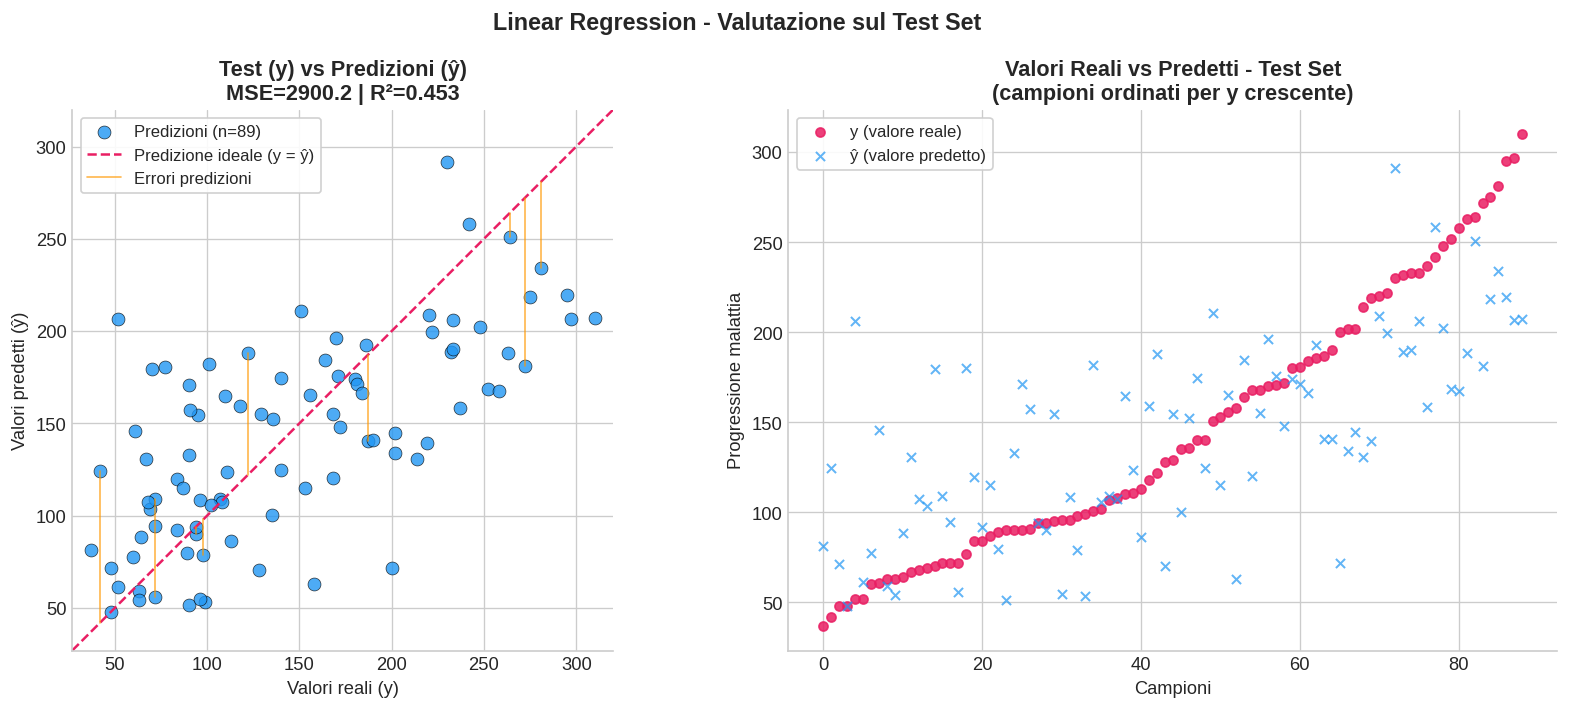

In [41]:
# VALUTAZIONE FINALE - LINEAR REGRESSION SUL TEST SET

from sklearn.metrics import mean_squared_error, r2_score

print('='*80)
print('VALUTAZIONE FINALE - LINEAR REGRESSION'.center(80))
print('='*80 + '\n')

# --- Addestramento sul training set completo ---
lr_final = LinearRegression()
lr_final.fit(X_train, y_train)

# --- Predizioni sul test set ---
y_pred_test = lr_final.predict(X_test)

# --- Metriche sul test set ---
mse_test  = mean_squared_error(y_test, y_pred_test)
r2_test   = r2_score(y_test, y_pred_test)

# --- Metriche sul training set (confronto) ---
y_pred_train = lr_final.predict(X_train)
mse_train    = mean_squared_error(y_train, y_pred_train)
r2_train     = r2_score(y_train, y_pred_train)

print('  Metriche sul Training Set:')
print(f'    MSE  : {mse_train:.2f}')
print(f'    R²   : {r2_train:.4f}')
print('-'*80 + '\n')

print('  Metriche sul Test Set:')
print(f'    MSE  : {mse_test:.2f}')
print(f'    R²   : {r2_test:.4f}')
print('-'*80 + '\n')

print(f'  NMSE CV (stima K-Fold): {lr_baseline_mean:.2f}')
print(f'  NMSE Test (valutazione finale): {-mse_test:.2f}')
print('='*80)

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Linear Regression - Valutazione sul Test Set', fontsize=14, fontweight='bold')

# Subplot sinistro: y_test vs y_pred con linea ideale ---
ax1 = axes[0]

ax1.scatter(
    y_test, y_pred_test,
    color=COLOR['blue'], edgecolors='k',
    linewidths=0.4, s=60, alpha=0.80,
    label=f'Predizioni (n={len(y_test)})'
)

lims = [min(y_test.min(), y_pred_test.min()) - 10,
        max(y_test.max(), y_pred_test.max()) + 10]
ax1.plot(lims, lims, color=COLOR['red'], linewidth=1.5,
         linestyle='--', label='Predizione ideale (y = ŷ)')

# Residui verticali su 10 campioni casuali
rng = np.random.default_rng(RANDOM_STATE)
idx_sample = rng.choice(len(y_test), size=10, replace=False)
for i in idx_sample:
    if i == idx_sample[0]:
            ax1.plot(
        [y_test[i], y_test[i]], [y_test[i], y_pred_test[i]],
        color=COLOR['yellow'], linewidth=1.0, alpha=0.7,
        label = 'Errori predizioni'
    )
    else:
        ax1.plot(
            [y_test[i], y_test[i]], [y_test[i], y_pred_test[i]],
            color=COLOR['yellow'], linewidth=1.0, alpha=0.7
        )

ax1.set_title(f'Test (y) vs Predizioni (ŷ)\nMSE={mse_test:.1f} | R²={r2_test:.3f}')
ax1.set_xlabel('Valori reali (y)')
ax1.set_ylabel('Valori predetti (ŷ)')
ax1.set_xlim(lims)
ax1.set_ylim(lims)
ax1.set_aspect('equal')
ax1.legend()

# Subplot destro: scatter sovrapposti ordinati per y_test crescente ---
ax2 = axes[1]
n       = len(y_test)
sort_idx = np.argsort(y_test)          # indici che ordinano y_test in modo crescente

ax2.scatter(
    range(n), y_test[sort_idx],
    color=COLOR['red'], s=30, alpha=0.85,
    label='y (valore reale)'
)
ax2.scatter(
    range(n), y_pred_test[sort_idx],
    color=COLOR['blue'], s=30, alpha=0.70,
    marker='x', linewidths=1.2,
    label='ŷ (valore predetto)'
)

ax2.set_title('Valori Reali vs Predetti - Test Set\n(campioni ordinati per y crescente)')
ax2.set_xlabel('Campioni')
ax2.set_ylabel('Progressione malattia')
ax2.legend()

plt.tight_layout()
plt.show()

### 4.2 Learning Curve

La **learning curve** mostra come variano il punteggio sul training set e il punteggio di cross-validation al crescere del numero di campioni utilizzati per l'addestramento.

È uno strumento diagnostico per identificare se il modello soffre di **alta varianza** (overfitting) o **alto bias** (underfitting) e dunque consente di verifcare se il modello è ben calibrato e stabile 

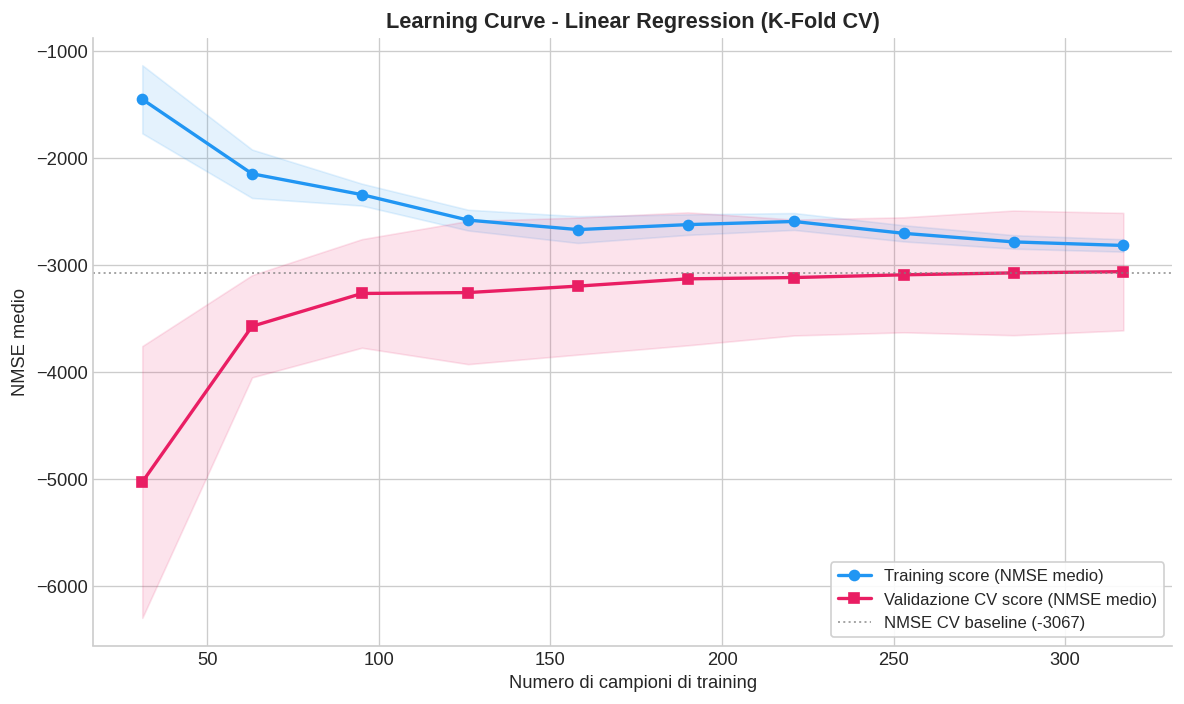

In [42]:
# LEARNING CURVE - LINEAR REGRESSION

from sklearn.model_selection import learning_curve

# --- Calcolo learning curve ---
# train_sizes: 10 punti da 10% a 100% del training set
TRAIN_SIZES = np.linspace(0.1, 1.0, 10)

train_sizes_abs, train_scores, val_scores = learning_curve(
    LinearRegression(),
    X_train, y_train,
    cv=kf,
    scoring='neg_mean_squared_error',
    train_sizes=TRAIN_SIZES
)

# Media e deviazione standard per ogni dimensione del training set
train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 6))

# Banda ±std training
ax.fill_between(
    train_sizes_abs,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.12, color=COLOR['blue']
)

# Banda ±std validazione
ax.fill_between(
    train_sizes_abs,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.12, color=COLOR['red']
)

# Curve medie
ax.plot(
    train_sizes_abs, train_mean,
    color=COLOR['blue'], linewidth=2, marker='o', markersize=6,
    label='Training score (NMSE medio)'
)
ax.plot(
    train_sizes_abs, val_mean,
    color=COLOR['red'], linewidth=2, marker='s', markersize=6,
    label='Validazione CV score (NMSE medio)'
)

# Linea di riferimento: NMSE baseline CV da sezione 2
ax.axhline(
    lr_baseline_mean, color='gray',
    linewidth=1.2, linestyle=':', alpha=0.7,
    label=f'NMSE CV baseline ({lr_baseline_mean:.0f})'
)

ax.set_title('Learning Curve - Linear Regression (K-Fold CV)')
ax.set_xlabel('Numero di campioni di training')
ax.set_ylabel('NMSE medio')
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

### Osservazioni

**Valutazione sul test set**

Il modello finale ottiene **MSE = 2900.19** e **R² = 0.4526** sul test set, in linea con la stima CV (NMSE = -3067). Il leggero aumento di MSE rispetto al training set (2868 → 2900) è trascurabile e indica assenza di overfitting. Il valore R² ≈ 0.45 è coerente con la letteratura su questo dataset: le 10 features spiegano circa il 45-50% della varianza nella progressione della malattia. Il modello ha capacità predittiva moderata ma stabile.

**Learning curve - diagnosi bias/varianza**

La forma delle curve rivela un comportamento tipico di **alto bias (underfitting)**:

- La **curva di training** parte da NMSE vicino a 0 con pochi campioni (il modello si adatta a un sottoinsieme piccolo) e scende stabilizzandosi poco sopra la baseline con l'aumentare dei dati.
- La **curva di validazione** parte da NMSE molto negativo (alta varianza con pochi dati) e risale convergendo verso la curva di training.
- Il **gap tra le due curve è piccolo e si chiude rapidamente**: nessun overfitting, il modello generalizza bene.
- Entrambe le curve **convergono al plateau della baseline** (~-3067): il modello ha raggiunto il suo limite di capacità espressiva.

Questo plateau indica che aggiungere ulteriori dati non porterebbe miglioramenti significativi. Per migliorare l'R² sarebbe necessario introdurre termini non lineari (feature engineering, interazioni) oppure modelli con maggiore capacità espressiva.

## 5. Visualizzazione con Data Reduction

### 5.1 PCA - Riduzione a 2 Componenti

La **PCA** (Principal Component Analysis) proietta le 10 features originali nelle due direzioni di massima varianza del dataset, permettendo di visualizzare la struttura dei dati in un piano 2D.

La PCA viene applicata **solo sul training set** (`fit_transform`) e poi il test set viene trasformato con la stessa proiezione (`transform`), per evitare data leakage.

                         PCA - RIDUZIONE A 2 COMPONENTI                         

  Varianza spiegata:
  - PC1        : 39.84%
  - PC2        : 14.70%
  - Tot        : 54.54%
  - Info persa : 45.46%


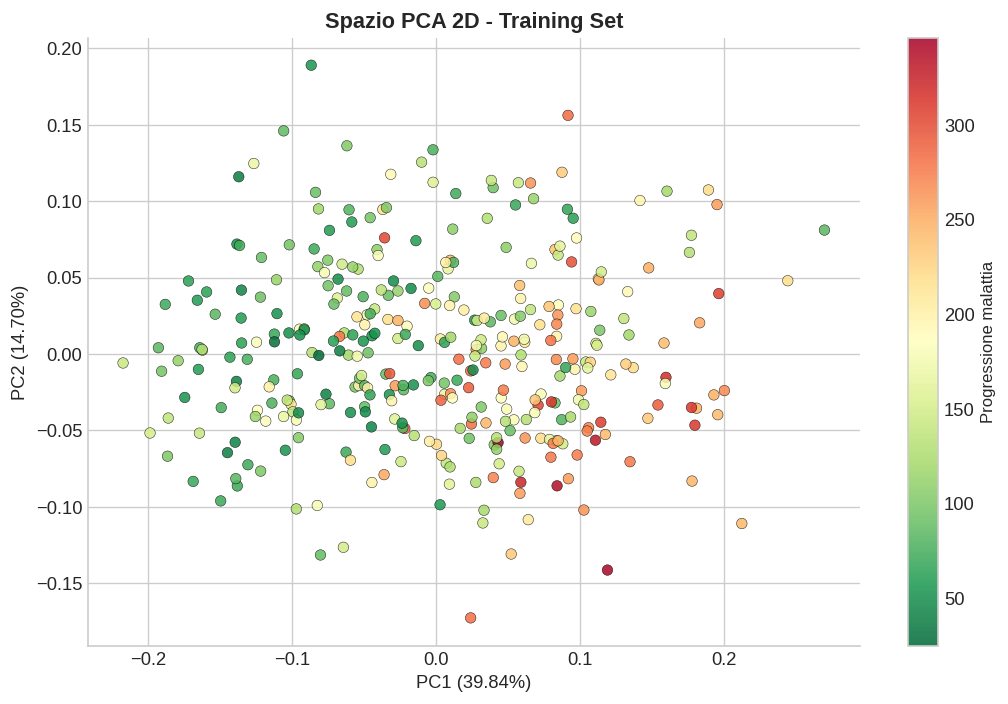

In [43]:
# PCA - RIDUZIONE A 2 COMPONENTI

from sklearn.decomposition import PCA

print('='*80)
print('PCA - RIDUZIONE A 2 COMPONENTI'.center(80))
print('='*80 + '\n')

# --- Fit su training set, transform su entrambi ---
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)   # fit solo su training — no leakage
X_test_pca  = pca.transform(X_test)

var1, var2 = pca.explained_variance_ratio_

print('  Varianza spiegata:')
print(f'  - PC1        : {var1:.2%}')
print(f'  - PC2        : {var2:.2%}')
print(f'  - Tot        : {var1 + var2:.2%}')
print(f'  - Info persa : {1 - (var1 + var2):.2%}')
print('='*80)

# --- Scatter 2D: spazio PCA colorato per valore del target ---
fig, ax = plt.subplots(figsize=(9, 6))

sc = ax.scatter(
    X_train_pca[:, 0], X_train_pca[:, 1],
    c=y_train, cmap='RdYlGn_r',
    s=40, alpha=0.85, edgecolors='k', linewidths=0.3
)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Progressione malattia', fontsize=10)

ax.set_title('Spazio PCA 2D - Training Set')
ax.set_xlabel(f'PC1 ({var1:.2%})')
ax.set_ylabel(f'PC2 ({var2:.2%})')

plt.tight_layout()
plt.show()

### 5.2 Regressione Lineare nello Spazio PCA

Un modello lineare addestrato su PC1 e PC2 definisce un **piano** nello spazio tridimensionale (PC1, PC2, target): ogni punto del piano corrisponde alla predizione del modello per quella coppia di valori (PC1, PC2).

L'equazione del piano è: 

$\hat{y} = w_0 + w_1 \cdot PC1 + w_2 \cdot PC2$

dove $w_0$ è l'intercetta e $w_1, \, w_2$ sono le pendenze lungo le due componenti principali.

Per la valutazione del modello si utilizza come metrica il coefficiente R² in quanto fornisce una misura diretta della bontà della regressione.

                        REGRESSIONE LINEARE - SPAZIO PCA                        

Coefficienti del piano di regressione:
  - Intercetta : 153.74
  - Coeff PC1  : 453.03
  - Coeff PC2  : -257.25
--------------------------------------------------------------------------------

  Performance:
  - R² su train PCA : 0.3405
  - R² su test  PCA : 0.3398
  - R² su test  10D : 0.4526


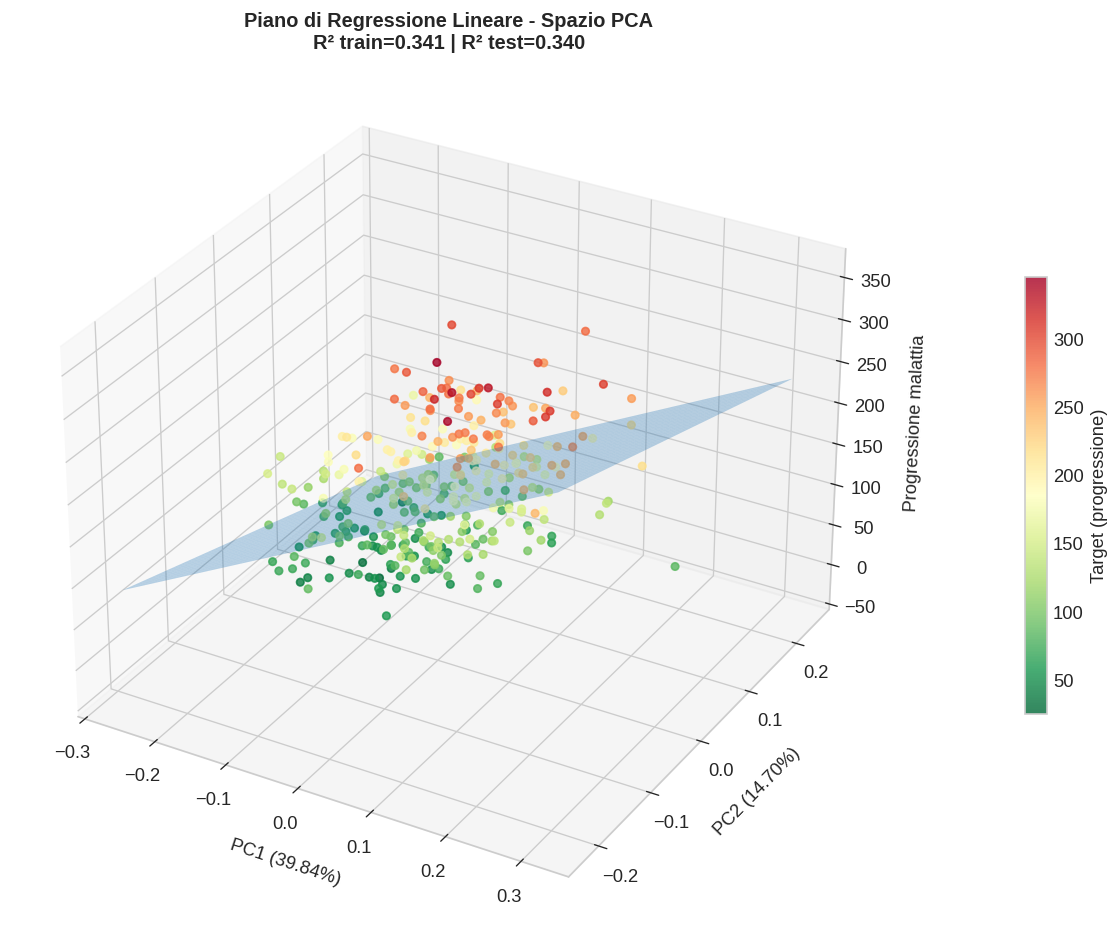

In [44]:
# REGRESSIONE LINEARE NELLO SPAZIO PCA + PIANO 3D

print('='*80)
print('REGRESSIONE LINEARE - SPAZIO PCA'.center(80))
print('='*80 + '\n')

# --- Addestramento su spazio PCA ---
lr_pca = LinearRegression()
lr_pca.fit(X_train_pca, y_train)

r2_pca_train = lr_pca.score(X_train_pca, y_train)
r2_pca_test  = lr_pca.score(X_test_pca,  y_test)

print('Coefficienti del piano di regressione:')
print(f'  - Intercetta : {lr_pca.intercept_:.2f}')
print(f'  - Coeff PC1  : {lr_pca.coef_[0]:.2f}')
print(f'  - Coeff PC2  : {lr_pca.coef_[1]:.2f}')
print('-'*80 + '\n')
print('  Performance:')
print(f'  - R² su train PCA : {r2_pca_train:.4f}')
print(f'  - R² su test  PCA : {r2_pca_test:.4f}')
print(f'  - R² su test  10D : {r2_test:.4f}')
print('='*80)

# --- Plot 3D: piano di regressione + scatter dati ---
from mpl_toolkits.mplot3d import Axes3D

# Griglia per il piano di regressione
pc1_range = np.linspace(
    X_train_pca[:, 0].min() - 0.05, 
    X_train_pca[:, 0].max() + 0.05, 40
)
pc2_range = np.linspace(
    X_train_pca[:, 1].min() - 0.05,
    X_train_pca[:, 1].max() + 0.05, 40
)
XX, YY = np.meshgrid(pc1_range, pc2_range)

# Predizioni del piano su tutta la griglia
ZZ = lr_pca.intercept_ + lr_pca.coef_[0] * XX + lr_pca.coef_[1] * YY

fig = plt.figure(figsize=(12, 8))
ax  = fig.add_subplot(111, projection='3d')

# Piano di regressione
ax.plot_surface(
    XX, YY, ZZ,
    alpha=0.30, color=COLOR['blue']
)

# Scatter punti training colorati per target
sc = ax.scatter(
    X_train_pca[:, 0], X_train_pca[:, 1], y_train,
    c=y_train, cmap='RdYlGn_r',
    s=20, alpha=0.80,
    label='Training set'
)

plt.colorbar(sc, ax=ax, shrink=0.5, pad=0.1, label='Target (progressione)')

ax.set_title(
    f'Piano di Regressione Lineare - Spazio PCA\n'
    f'R² train={r2_pca_train:.3f} | R² test={r2_pca_test:.3f}',
    fontsize=12
)
ax.set_xlabel(f'PC1 ({var1:.2%})', labelpad=8)
ax.set_ylabel(f'PC2 ({var2:.2%})', labelpad=8)
ax.set_zlabel('Progressione malattia', labelpad=8)

plt.tight_layout()
plt.show()

### Osservazioni

**PCA**: PC1 (39.84%) e PC2 (14.70%) spiegano complessivamente il **54.54%** della varianza totale delle features. Il 45.46% restante è distribuito nelle 8 componenti escluse, e contiene informazione che il modello ridotto non può sfruttare.

**Piano di regressione**: il coefficiente di PC1 (w₁ = 453.03) è quasi il doppio in valore assoluto di quello di PC2 (w₂ = −257.25), confermando che **PC1 è la direzione più predittiva**. Il segno negativo di w₂ indica che valori alti di PC2 corrispondono a una progressione più bassa - una relazione inversa catturata dalla seconda componente. L'intercetta (153.74) coincide con la media del target sul training set, come atteso per un modello lineare.

**Confronto R²**: il calo da R² = 0.45 (spazio 10D) a R² = 0.34 (spazio PCA) è conseguenza diretta della compressione dimensionale. Il dato interessante è che R² su train e test PCA sono praticamente identici (0.3405 vs 0.3398): il modello ridotto generalizza perfettamente, senza overfitting, perché la semplificazione estrema a 2 dimensioni elimina qualsiasi componente di rumore. La dispersione dei punti attorno al piano di regressione nel grafico 3D riflette esattamente questa perdita di potere predittivo.